# AT2017gfo vista por Roman — nota para la discusión

Material para la **discusión**, no para resultados: las métricas del clasificador (matriz de
confusión, precision-recall, desglose por contaminante) ya están medidas sobre el test split en
`training/evaluation.ipynb`. Lo que falta decir ahí es una sola frase, y esta nota la sostiene:

> *Aplicado a la única kilonova con serie espectroscópica observada, AT2017gfo, el clasificador la
> identifica con P(KN) = … a partir de una sola época de Roman.*

## Cómo

La serie de VLT/X-shooter de ENGRAVE (10 épocas, +1.43 d a +10.40 d desde el merger,
3300–24000 Å, calibrada espectrofotométricamente contra la fotometría publicada) se integra contra
los bandpasses de `galsim.roman` y de ahí sale una ventana con la cadencia y la receta de ruido del
HLTDS.

**En el frame observado, tal cual.** Se usan los espectros calibrados sin des-enrojecer y sin
des-redshiftear: el redshift de NGC 4993 y la extinción de la Vía Láctea quedan dentro del flujo,
que es la única cosmología que el observable trae consigo. Eso deja la curva **fuera del set de
entrenamiento** a propósito — ninguna kilonova LANL del training lleva extinción, y los
contaminantes de OpenUniverse llevan host pero no Vía Láctea.

**Un objeto, pero no un solo número.** La versión anterior de esta nota clavaba la primera visita
en +1.43 d y anulaba el sorteo de ruido, y salía un número puntual. Acá se barren los dos ejes que
el dato sí soporta:

1. **La fase de la primera visita**, de +1.43 d (la primera fase con espectro) a +5.40 d. Más allá
   de +5.40 d la segunda visita de la cadencia de 5 d se sale del final de la serie (+10.40 d) y el
   régimen de 2 épocas deja de existir. La primera visita de Roman cae donde cae; el barrido dice
   cuánto de la respuesta depende de esa suerte.
2. **La realización de ruido de Roman**, ahora sí sorteada. `build_window_from_model` sortea el
   jitter de zeropoint por (banda, visita) y el flujo observado en espacio de flujo; antes se le
   devolvía la magnitud verdadera a las detecciones y eso mataba la única fuente de dispersión.

Lo que **no** se sortea: el ángulo de visión, los parámetros de eyecta y la calibración de flujo de
X-shooter. Es un objeto y una curva.

## Sobre el error fotométrico

El error **sí** entra al modelo, y siempre entró: `sigma_magnitude` es una de las cuatro features
fotométricas por token (`training/model.py`, `NUM_MAGNITUDE_FEATURES = 4`), y se llena con el
`mag_err = 1.0857 / SNR` que la receta de Roman produce para esa banda, ese tier y esa exposición.
Lo que faltaba era la **realización**: la magnitud observada era la verdadera.

Conviene decir de entrada que a este brillo eso importa poco. AT2017gfo llega a las bandas de Roman
entre 17.5 y 22.5 AB, y los límites de 5σ por visita del HLTDS están entre 25.5 y 27.2, así que la
primera visita la mide con S/N de orden 10³ y `mag_err ≈ 0.001 mag` — cuarenta veces más fino que el
error típico del set de entrenamiento (`SIGMA_MAG_MEAN = 0.093`). El Monte Carlo se hace igual,
porque es lo correcto, pero el resultado esperado es que no mueva nada: **esta curva está limitada
por sus colores, no por su ruido.**

Hay además una propiedad del generador que conviene tener presente al leer la dispersión: el jitter
de zeropoint entra en `flux_true` y vuelve a salir en `mag_observed`, porque la magnitud se
reconstruye con el mismo zeropoint jitterizado con que se calculó el flujo. O sea que los 0.15 mag
de `ZP_JITTER_SIGMA` **no** dispersan la magnitud recuperada; solo mueven el S/N y el límite de 5σ.
Es el mismo comportamiento que tuvo el set de entrenamiento.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPOSITORY_ROOT = Path.cwd().parents[1] if Path.cwd().name == "validation" else Path.cwd()
sys.path.insert(0, str(REPOSITORY_ROOT / "training"))
sys.path.insert(0, str(REPOSITORY_ROOT / "notebooks/validation"))

from observed_photometry import load_smartt_photometry, perturb_synthetic_magnitudes  # noqa: E402

from kilonova.photometry.roman_noise import build_tier_constants  # noqa: E402
from kilonova.photometry.spectra import ALL_ROMAN_BANDS, spectrum_to_roman_magnitudes  # noqa: E402
from kilonova.simulation.early_windows import (  # noqa: E402
    BASE_CADENCE_DAYS,
    KN_GENTYPE,
    N_KN_VISITS,
    build_window_from_model,
)

# ----------------------------------------------------------------------------- AT2017gfo
# El espectro entra en el frame observado: el redshift de la anfitriona solo viaja como token.
HOST_REDSHIFT = 0.0098  # NGC 4993

RELEASE_DIR = REPOSITORY_ROOT / "data/at2017gfo"
XSHOOTER_DIR = RELEASE_DIR / "AT2017gfo/flux_corrected_smoothed_joined_spectra"
PHOTOMETRY_FILE = RELEASE_DIR / "AT2017gfo_phot_compiled_sjs.dat"

PHASE_GRID_STEP_DAYS = 0.1  # remuestreo de las 10 fases antes del lookup de visita
REFERENCE_VISIT_PHASE_DAYS = 1.43  # la fase de la nota anterior, conservada como caso de referencia
# Anclas de la primera visita: hasta 5.40 d, que es donde la 2a visita (ancla + 5 d) todavia cae
# dentro de la serie (+10.40 d). Mas alla el regimen de 2 epocas no existe.
ANCHOR_PHASE_GRID = np.round(np.arange(1.43, 5.41, PHASE_GRID_STEP_DAYS), 2)
NOISE_REALIZATIONS = 64
# Corriente aleatoria de la calibracion espectrofotometrica, separada de la del ruido de Roman que
# `build_window_from_model` siembra con el mismo noise_seed.
CALIBRATION_STREAM_KEY = 1
CADENCE_PARITY = 0  # la secuencia nominal del HLTDS: ZYJ/ZHF en deep, RZY/RJH en wide
EPOCH_REGIMES = (1, 2)
DECISION_THRESHOLDS = (0.5, 0.2)  # los dos umbrales que usa run_evaluation_test_only.py

CHECKPOINT = REPOSITORY_ROOT / "training/checkpoints/kilonova_transformer-soup.ckpt"
NORMALIZATION_FILE = REPOSITORY_ROOT / "data/openuniverse/normalization.json"

BAND_COLOR = {
    "R062": "#5A189A",
    "Z087": "#3A86FF",
    "Y106": "#06A77D",
    "J129": "#F0A202",
    "H158": "#D62828",
    "F184": "#6A040F",
}
TIER_COLOR = {"deep": "#FB5607", "wide": "#3A86FF"}
EPOCH_STYLE = {1: "-", 2: "--"}

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})


# ----------------------------------------------------------------------------- plot functions
# El formateador por defecto del eje logit etiqueta la mitad de arriba como "1 - 10^-4", que es
# justo la lectura al reves que se quiere evitar: el numero que interesa es P(KN). Se fijan ticks
# explicitos con la etiqueta decimal escrita entera.
LOGIT_TICKS = [0.2, 0.5, 0.9, 0.99, 0.999, 0.9999, 0.99999]


def set_probability_axis(panel):
    """Eje y = P(KN) en escala logit, con ticks decimales legibles y sin menores."""
    panel.set_yscale("logit")
    panel.set_ylim(0.15, 1.0 - 1e-6)
    panel.set_yticks(LOGIT_TICKS)
    panel.set_yticklabels([f"{tick:g}" for tick in LOGIT_TICKS])
    panel.yaxis.set_minor_locator(matplotlib.ticker.NullLocator())


def plot_roman_light_curve(magnitudes, photometry, axis=None):
    """Curva sintetica de Roman contra la fotometria publicada, ambas observadas (enrojecidas)."""
    if axis is None:
        _, axis = plt.subplots(figsize=(7.5, 4.6))
    for band in ALL_ROMAN_BANDS:
        values = magnitudes[band].to_numpy()
        axis.plot(
            magnitudes.index.to_numpy(),
            values,
            marker="o",
            markersize=3.5,
            lw=1.4,
            color=BAND_COLOR[band],
            label=band,
        )
    for filter_name, marker in zip(["z", "y", "J", "H"], ["s", "D", "v", "^"], strict=True):
        subset = photometry.dropna(subset=[filter_name])
        axis.plot(subset["phase"], subset[filter_name], marker, ms=4, mfc="none", color="0.35", lw=0)
    axis.invert_yaxis()
    axis.set_xlabel("días observador desde el merger")
    axis.set_ylabel("magnitud AB")
    axis.set_title("AT2017gfo en las bandas de Roman, frame observado\n(gris hueco: fotometría zyJH publicada)")
    axis.legend(ncol=3, fontsize=7, frameon=False)


def plot_window(windows_by_tier, axis=None):
    """La ventana que ve el clasificador: detecciones con su error y limites 5 sigma."""
    if axis is None:
        _, axis = plt.subplots(1, len(windows_by_tier), figsize=(5.4 * len(windows_by_tier), 4.0), sharey=True)
    axes = np.atleast_1d(axis)
    for panel, (tier, window) in zip(axes, windows_by_tier.items(), strict=True):
        observed = window[window["observed"]]
        for band in sorted(observed["band"].unique(), key=ALL_ROMAN_BANDS.index):
            block = observed[observed["band"] == band]
            detections = block[block["detected"]]
            limits = block[~block["detected"]]
            panel.errorbar(
                detections["days_since_detection"],
                detections["mag_observed"],
                yerr=detections["mag_err"],
                fmt="o",
                ms=6,
                color=BAND_COLOR[band],
                label=band,
            )
            panel.plot(
                limits["days_since_detection"], limits["mag_limit_5sigma"], "v", ms=7, mfc="none",
                color=BAND_COLOR[band],
            )
        for epoch_day in sorted(observed["days_since_detection"].unique()):
            panel.axvline(epoch_day, color="0.6", lw=0.7, ls=":")
        panel.set_title(f"tier {tier}", fontsize=10, color=TIER_COLOR[tier])
        panel.set_xlabel("días desde la primera detección")
        panel.legend(fontsize=7, ncol=2, frameon=False)
    axes[0].invert_yaxis()
    axes[0].set_ylabel("magnitud AB")
    axes[0].figure.suptitle("La ventana de Roman de AT2017gfo (triángulo hueco: no detección)", fontsize=10)


def plot_probability_vs_phase(summary, axis=None):
    """P(KN) en funcion de donde caiga la primera visita de Roman.

    El eje y es logit: la escala natural de una probabilidad que vive pegada a 1. En lineal las
    ocho curvas serian ocho rayas sobre el techo, y en un eje log de 1 - P(KN) habria que leer la
    figura al reves. Con logit el numero ploteado es P(KN) y las divisiones (0.5, 0.9, 0.99, ...)
    quedan igual de separadas, asi que se ve a la vez la estructura con la fase y la distancia a los
    umbrales de decision."""
    tiers = list(dict.fromkeys(summary["tier"]))
    if axis is None:
        _, axis = plt.subplots(1, len(tiers), figsize=(5.6 * len(tiers), 5.0), sharey=True)
    axes = np.atleast_1d(axis)
    for panel, tier in zip(axes, tiers, strict=True):
        for epochs in EPOCH_REGIMES:
            for has_redshift in (False, True):
                block = summary[
                    (summary["tier"] == tier)
                    & (summary["epochs"] == epochs)
                    & (summary["has_redshift"] == has_redshift)
                ].sort_values("anchor_phase_days")
                if len(block) == 0:
                    continue
                phase = block["anchor_phase_days"].to_numpy()
                panel.fill_between(
                    phase,
                    block["percentile_16"].to_numpy(),
                    block["percentile_84"].to_numpy(),
                    color=TIER_COLOR[tier],
                    alpha=0.18,
                    lw=0,
                )
                panel.plot(
                    phase,
                    block["median"].to_numpy(),
                    EPOCH_STYLE[epochs],
                    color=TIER_COLOR[tier],
                    alpha=1.0 if not has_redshift else 0.45,
                    lw=1.6,
                    label=f"{epochs} ép., {'con z' if has_redshift else 'sin z'}",
                )
        for threshold, horizontal in zip(DECISION_THRESHOLDS, ["left", "right"], strict=True):
            panel.axhline(threshold, color="0.3", lw=0.9, ls=":")
            panel.text(
                phase[0] if horizontal == "left" else phase[-1],
                threshold,
                f"umbral {threshold} ",
                fontsize=7,
                color="0.3",
                ha=horizontal,
                va="bottom",
            )
        set_probability_axis(panel)
        panel.set_xlabel("fase de la primera visita [d desde el merger]")
        panel.set_title(f"tier {tier}", fontsize=10, color=TIER_COLOR[tier])
        panel.legend(fontsize=7, frameon=False, loc="lower center")
    axes[0].set_ylabel("P(KN)")
    figure = axes[0].figure
    figure.suptitle(
        "AT2017gfo: P(KN) según cuándo apunte Roman\n"
        f"(banda: 16–84 % sobre {NOISE_REALIZATIONS} realizaciones de calibración + ruido; eje y logit)",
        fontsize=10,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.93))


print(f"repositorio: {REPOSITORY_ROOT}")
print(f"{len(ANCHOR_PHASE_GRID)} anclas de {ANCHOR_PHASE_GRID[0]} a {ANCHOR_PHASE_GRID[-1]} d")

repositorio: /Users/bhianca/Kilonova
40 anclas de 1.43 a 5.33 d


## 1. De la serie de X-shooter a las bandas de Roman

Los espectros entran **en el frame observado**: `flux_corrected_smoothed_joined_spectra`, tal como
salen del telescopio una vez calibrados a la fotometría publicada, con el redshift de NGC 4993 y la
extinción de la Vía Láctea dentro del flujo. No se des-enrojecen, no se des-redshiftean, no se
reescalan a 10 pc — el flujo que se integra contra los bandpasses es el que Roman mediría, y la
cosmología es la que el observable ya trae. Por eso se llama a `spectrum_to_roman_magnitudes` y no
a `magnitudes_for_bands`: esta última es el camino del training, que toma una SED en reposo a 10 pc
y la coloca a un redshift.

**Y por eso el caso es difícil.** Las kilonovas LANL del entrenamiento no llevan extinción de
ninguna clase, y los contaminantes de OpenUniverse llevan la de la anfitriona pero no la galáctica
(`mw_extinction_applied=False`). AT2017gfo entra con $E(B-V) = 0.105$ de la Vía Láctea puesta, que
con F99 y $R_V = 3.1$ son 0.27 mag en R062, 0.16 en Z087 y 0.11 en Y106 — es decir, un R062−Z087
enrojecido en 0.11 mag respecto de cualquier objeto que el modelo haya visto. La pregunta que
responde esta nota es si el clasificador la sigue reconociendo así.

**El error de una magnitud sintética.** Integrar un espectro no produce una medición sin
incerteza, pero la incerteza no es la que uno espera. Propagando la columna de error de los
ficheros de ENGRAVE por la integral del bandpass — $\sigma^2(F) = \sum_i (w_i\,\sigma_i)^2$ con
$w_i = \lambda_i T(\lambda_i)\,\Delta\lambda_i$ — salen entre 0.0003 y 0.007 mag en los primeros
cinco días: miles de píxeles promediando. (Y106 sale 3–5× peor que sus vecinas porque cae sobre las
bandas telúricas de H$_2$O en 0.94 y 1.13 µm, que es una señal real y no un artefacto.) Ese término
es despreciable.

El que manda es el **error de la calibración espectrofotométrica**, y el release lo mide por
nosotros: el README tabula la fotometría observada contra la sintética época a época *después* del
reescalado, y en las bandas que no se usaron para restringir el ajuste — $r$, $H$, $K$ — los
residuos dispersan 0.08–0.17 mag, consistente con el "agreement mostly to better than 5 % (0.05
mag)" que el propio release declara. Del mismo orden que lo que reporta la literatura de fotometría
sintética en general (Bessell & Murphy 2012; Gaia Collaboration / Montegriffo et al. 2023, que
además encuentran las incertezas propagadas nominales sistemáticamente subestimadas).

Ese error **no son seis gaussianas independientes**. A cada espectro se le aplicó una corrección de
la forma $F \to a\,(1 + b\lambda)\,F$, así que tiene una componente gris compartida por todas las
bandas y un *tilt* cromático. Un clasificador que lee colores casi no siente la primera y se mueve
con el segundo, de modo que colapsar ambas en ruido por banda desplazaría el resultado en un sentido
o el otro según el signo. `perturb_synthetic_magnitudes` sortea $(\text{gris}, \text{tilt})$ una vez
por realización: $\sigma$ por banda va de 0.05 mag en el medio del rango a 0.078 en R062 y F184, y
el color R062−F184 dispersa 0.11 mag.

**Un caso concreto que hay que mirar antes de leer las figuras.** El +5.40 d es un outlier
documentado: ENGRAVE reporta $r$ observado $20.79\pm0.24$ contra $20.43$ sintético, 0.36 mag. Mi
integración da R062 = 20.34 en +5.40 d contra 20.36 en +4.40 d — la curva se aplana justo ahí, y
R062 es la banda ancla del tier *wide*. Y el brazo UVB de +8.40 d fue descartado por ENGRAVE, así
que esa época devuelve `R062 = NaN` y `model_from_magnitudes` interpola en línea recta entre +7.40 y
+9.40 d (0.55 mag en 2 d, inocuo, pero conviene decirlo en vez de esconderlo).

**Verificación**: la curva sintética se superpone a la fotometría publicada
(`AT2017gfo_phot_compiled_sjs.dat`, la compilación de Smartt usada en Coughlin et al. 2018) tal como
está, sin reescalar. El parser de esa tabla vive ahora en `observed_photometry.py`, que es también
el módulo del notebook fotométrico (`observed_photometry_roman_prediction.ipynb`), para que las dos
notas lean el mismo fichero de la misma manera.

10 épocas, fases 1.43 -> 10.40 d observador


,R062,Z087,Y106,J129,H158,F184
phase_days,,,,,,
1.43,18.03,17.71,17.50,17.54,17.57,17.54
2.42,19.10,18.31,17.78,17.64,17.58,17.28
3.41,19.77,18.70,18.00,17.87,17.70,17.59
4.40,20.36,19.05,18.18,18.10,17.89,17.96
5.40,20.34,19.13,18.46,18.39,18.18,18.11
6.40,20.74,19.59,18.85,18.60,18.33,18.02
7.40,21.18,20.10,19.41,19.19,18.78,18.58
8.40,NaN,20.32,19.85,19.75,19.26,19.09
9.40,21.73,20.99,20.51,20.17,19.64,19.27


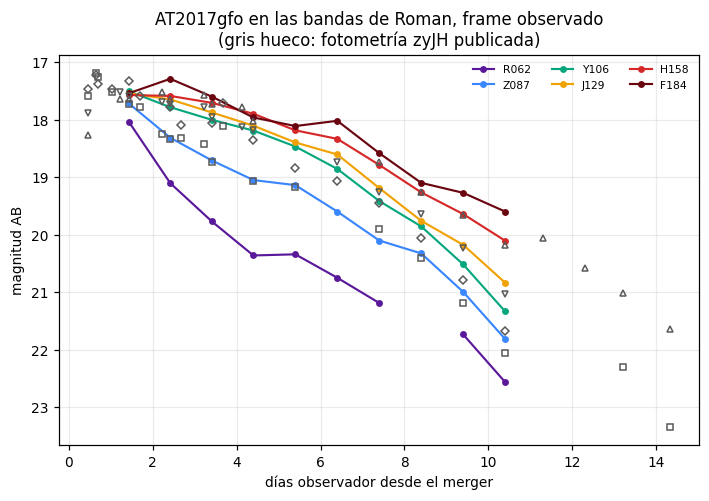

In [2]:
def load_engrave_series(spectra_directory):
    """Las 10 epocas de X-shooter -> {fase [d observador desde el merger]: (lambda obs [AA], F_lambda obs)}.

    Columna 1 = flujo corregido de teluricas. El flujo se toma tal cual: enrojecido, al redshift de
    la anfitriona y a su distancia."""
    series = {}
    for path in sorted(spectra_directory.glob("*Phase+*d.dat")):
        phase = float(path.name.split("Phase+")[1].removesuffix("d.dat"))
        table = np.loadtxt(path, comments="#", usecols=(0, 1))
        finite = np.isfinite(table[:, 0]) & np.isfinite(table[:, 1])
        series[phase] = (table[finite, 0], table[finite, 1])
    return dict(sorted(series.items()))


def roman_magnitudes_by_phase(series, photometry, plot=True):
    """Magnitud AB de Roman en cada fase tabulada, integrando el espectro observado tal cual.

    NaN = el espectro no cubre la banda; +inf = la cubre y no hay flujo."""
    rows = []
    for phase, (wavelength_observed_aa, flux_observed_lambda) in series.items():
        rows.append(
            {"phase_days": phase, **spectrum_to_roman_magnitudes(wavelength_observed_aa, flux_observed_lambda)}
        )
    magnitudes = pd.DataFrame(rows).set_index("phase_days")
    if plot:
        plot_roman_light_curve(magnitudes, photometry)
    return magnitudes


engrave_series = load_engrave_series(XSHOOTER_DIR)
compiled_photometry = load_smartt_photometry(PHOTOMETRY_FILE)
roman_magnitudes = roman_magnitudes_by_phase(engrave_series, compiled_photometry, plot=True)
print(f"{len(engrave_series)} épocas, fases {min(engrave_series):.2f} -> {max(engrave_series):.2f} d observador")
display(roman_magnitudes.round(2))

## 2. Las ventanas de Roman

Se llama a `build_window_from_model`, la misma función que produjo cada fila de
`kn_windows_{deep,wide}.parquet`. Lo único que cambia es de dónde salen las magnitudes verdaderas.

Las elecciones fijas:

- **Paridad de cadencia 0**, la secuencia nominal publicada del HLTDS: ZYJ / ZHF en deep,
  RZY / RJH en wide. La primera visita ve tres de las cinco bandas del tier; las otras dos entran
  como tokens de tipo `n`, igual que en el entrenamiento.
- Las magnitudes verdaderas se remuestrean a 0.1 d antes de entrar: las 10 fases tabuladas están a
  ~1 día y la kilonova cae ~0.3 mag/día, así que el lookup de vecino más cercano de
  `build_window_from_model` costaría hasta 0.15 mag.

Y los ejes que se barren:

- **La fase de la primera visita**, `ANCHOR_PHASE_GRID`, de +1.43 a +5.40 d en pasos de 0.1 d.
- **La realización**, de 0 a 63, que sortea las dos incertezas del problema en el orden en que
  ocurren: primero la **calibración espectrofotométrica** (`calibration_shifted_model`, gris + tilt,
  que mueve las magnitudes verdaderas), y después el **ruido de Roman** que `build_window_from_model`
  pone encima. Las dos corrientes aleatorias son independientes. La banda 16–84 % de las figuras es
  la suma de ambas; en la versión anterior de esta nota tenía solo la segunda, que es justamente la
  que no domina.

La ventana de referencia (+1.43 d, sin ruido) se conserva aparte: es la que produjo la tabla de la
versión anterior de esta nota y sirve de control de regresión más abajo.

deep: 2 épocas cubiertas, 6 detecciones, 0 no detecciones, mag_err 0.0007–0.0037
wide: 2 épocas cubiertas, 6 detecciones, 0 no detecciones, mag_err 0.0015–0.0099


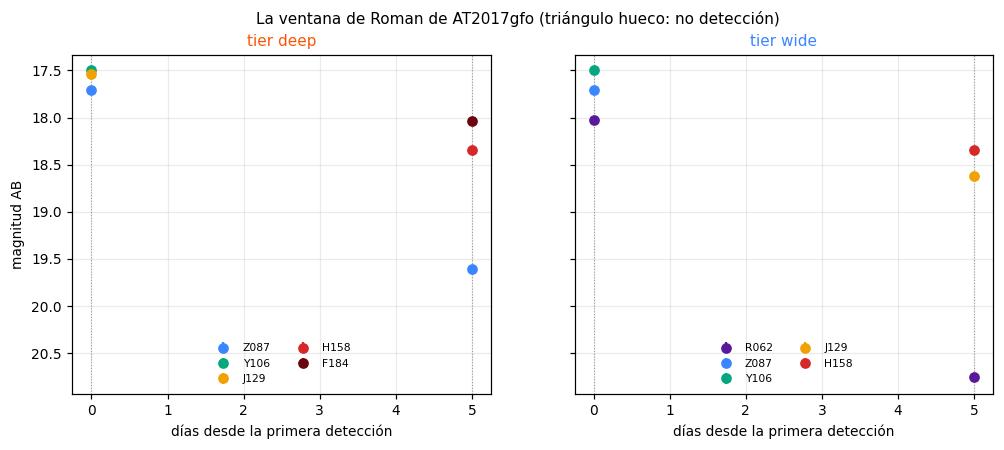

In [3]:
def model_from_magnitudes(magnitudes_by_phase):
    """{banda: (dias observador desde el merger, mag AB)} en una grilla densa de fase."""
    model = {}
    for band in ALL_ROMAN_BANDS:
        values = magnitudes_by_phase[band].to_numpy()
        usable = np.isfinite(values)
        phases = magnitudes_by_phase.index.to_numpy()[usable]
        dense = np.arange(phases.min(), phases.max() + PHASE_GRID_STEP_DAYS, PHASE_GRID_STEP_DAYS)
        model[band] = (dense, np.interp(dense, phases, values[usable]))
    return model


def calibration_shifted_model(model_6band, noise_seed):
    """El modelo de 6 bandas con un sorteo de la calibracion espectrofotometrica encima.

    El error de una magnitud integrada de un espectro no es de medicion: propagando la columna de
    error de los ficheros de ENGRAVE por la integral del bandpass salen 0.0003-0.007 mag en los
    primeros cinco dias, porque promedian miles de pixeles. Lo que si pesa es el error del escalado
    a flujo que puso al espectro en esa escala, y el propio release lo mide: su README tabula
    fotometria contra fotometria sintetica epoca a epoca despues del reescalado, y en las bandas que
    NO se usaron para ajustarlo (r, H, K) los residuos dispersan 0.08-0.17 mag. `perturb_synthetic_
    magnitudes` sortea eso como gris + tilt, que es la forma que tenia la correccion aplicada.

    El sorteo es un desplazamiento constante en fase: una realizacion es una calibracion, no un
    ruido por epoca. Y se siembra con `noise_seed` solo, sin el ancla ni el tier: asi la realizacion
    k es el mismo universo en todo el barrido y P(KN) contra fase se lee como una curva en vez de
    como 40 sorteos independientes."""
    random_generator = np.random.default_rng([CALIBRATION_STREAM_KEY, int(noise_seed)])
    offsets = perturb_synthetic_magnitudes(dict.fromkeys(ALL_ROMAN_BANDS, 0.0), random_generator)
    return {
        band: (phases, magnitudes + offsets[band])
        for band, (phases, magnitudes) in model_6band.items()
    }


def build_observed_window(object_id, model_6band, redshift, tier_constants, anchor_phase_days, noise_seed):
    """La ventana de AT2017gfo en un tier, con la realizacion de ruido de Roman puesta."""
    model_tier = {band: curve for band, curve in model_6band.items() if band in set(tier_constants["bands"])}
    window = build_window_from_model(
        object_id,
        model_tier,
        tier_constants,
        redshift,
        KN_GENTYPE,
        base_epochs=anchor_phase_days + BASE_CADENCE_DAYS * np.arange(N_KN_VISITS),
        noise_seed=noise_seed,
        visit_index_offset=CADENCE_PARITY,
    )
    window["tier"] = tier_constants["tier"]
    return window


def build_reference_window(model_6band, redshift, tier_constants):
    """La ventana de la version anterior de la nota: ancla en +1.43 d y sin sorteo.

    Se le devuelve la magnitud verdadera a las detecciones, que es lo que la hacia determinista. El
    SNR, el error y el limite de 5 sigma no dependen del sorteo, asi que se conservan tal cual."""
    window = build_observed_window(
        f"AT2017gfo_{tier_constants['tier']}", model_6band, redshift, tier_constants,
        REFERENCE_VISIT_PHASE_DAYS, noise_seed=0,
    )
    detected = window["detected"].to_numpy()
    window.loc[detected, "mag_observed"] = window.loc[detected, "mag_true"]
    return window


roman_model = model_from_magnitudes(roman_magnitudes)
tier_constants_by_tier = {tier: build_tier_constants(tier) for tier in ("deep", "wide")}

reference_windows = {
    tier: build_reference_window(roman_model, HOST_REDSHIFT, constants)
    for tier, constants in tier_constants_by_tier.items()
}
plot_window(reference_windows)

for tier, window in reference_windows.items():
    observed = window[window["observed"]]
    print(
        f"{tier:4s}: {observed['days_since_detection'].nunique()} épocas cubiertas, "
        f"{int(observed['detected'].sum())} detecciones, {int((~observed['detected']).sum())} no detecciones, "
        f"mag_err {observed['mag_err'].min():.4f}–{observed['mag_err'].max():.4f}"
    )

In [4]:
def build_sweep(model_6band, redshift, tier_constants_by_tier, anchor_grid, n_realizations):
    """Todas las ventanas del barrido en un solo frame largo.

    Cada realizacion sortea las dos incertezas del problema y en el orden en que ocurren: primero la
    calibracion espectrofotometrica del espectro, que mueve las magnitudes verdaderas, y despues el
    ruido de Roman, que `build_window_from_model` pone sobre ellas. La banda de percentiles de las
    figuras es la suma de ambas; antes solo tenia la segunda, que es la que no domina.

    El `object_id` codifica (tier, ancla, semilla) porque es lo unico que sobrevive a la
    tokenizacion: `_read_long_parquet` agrupa por el, y de ahi se recuperan los tres ejes."""
    windows = []
    shifted_models = {
        noise_seed: calibration_shifted_model(model_6band, noise_seed)
        for noise_seed in range(n_realizations)
    }
    for tier, constants in tier_constants_by_tier.items():
        for anchor_phase_days in anchor_grid:
            for noise_seed in range(n_realizations):
                object_id = f"AT2017gfo_{tier}_{anchor_phase_days:05.2f}_{noise_seed:04d}"
                windows.append(
                    build_observed_window(
                        object_id, shifted_models[noise_seed], redshift, constants,
                        anchor_phase_days, noise_seed,
                    )
                )
    return pd.concat(windows, ignore_index=True)


sweep_windows = build_sweep(
    roman_model, HOST_REDSHIFT, tier_constants_by_tier, ANCHOR_PHASE_GRID, NOISE_REALIZATIONS
)
print(f"{sweep_windows['object_id'].nunique()} ventanas, {len(sweep_windows)} filas")

5120 ventanas, 102400 filas


## 3. Qué dice el clasificador

La tokenización pasa por `openuniverse_data._read_long_parquet`, no por una copia local: mismos
tipos de token (`d` detección / `u` límite superior / `n` no observado), misma magnitud por tipo,
mismo orden `(objeto, día, banda)`, y la normalización ajustada sobre el split de train.

Cuatro regímenes, los que la serie sostiene: **{1, 2 épocas} × {sin z, con z}**. El caso realista es
**sin z** — un candidato recién detectado no tiene redshift, y además el modelo se seleccionó por
`val_acc_noz` porque KN y contaminantes son casi disjuntos en redshift en el set de entrenamiento.

Primero el control de regresión sobre la ventana de referencia (debe reproducir la tabla de la
versión anterior de la nota), y después el barrido completo.

In [5]:
from observed_photometry import classify_windows, load_classifier  # noqa: E402

device = "cuda" if torch.cuda.is_available() else "cpu"
classifier, normalization = load_classifier(CHECKPOINT, NORMALIZATION_FILE, device)
print(normalization)


def classify_all_regimes(windows_frame, parquet_path, classifier, device):
    """P(KN) por objeto en los cuatro regimenes {1, 2 epocas} x {sin z, con z}."""
    predictions = []
    for epochs in EPOCH_REGIMES:
        for has_redshift in (False, True):
            block = classify_windows(windows_frame, parquet_path, classifier, device, epochs, has_redshift)
            block["epochs"] = epochs
            block["has_redshift"] = has_redshift
            predictions.append(block)
    return pd.concat(predictions, ignore_index=True)


reference_predictions = classify_all_regimes(
    pd.concat(reference_windows.values(), ignore_index=True),
    RELEASE_DIR / "at2017gfo_roman_window.parquet",
    classifier,
    device,
)
reference_predictions["tier"] = reference_predictions["object_id"].str.split("_").str[-1]
reference_predictions = (
    reference_predictions[["tier", "epochs", "has_redshift", "kn_probability"]]
    .sort_values(["tier", "epochs", "has_redshift"])
    .reset_index(drop=True)
)
reference_predictions.to_csv(RELEASE_DIR / "at2017gfo_roman_prediction.csv", index=False)
display(reference_predictions.round(4))

{'MAG_MEAN': 24.920455932617188, 'MAG_STD': 1.6659404039382935, 'SIGMA_MAG_MEAN': 0.09271068871021271, 'SIGMA_MAG_STD': 0.06418276578187943}


,tier,epochs,has_redshift,kn_probability
0,deep,1,False,0.9998
1,deep,1,True,0.9999
2,deep,2,False,0.9991
3,deep,2,True,0.9998
4,wide,1,False,0.9997
5,wide,1,True,0.9999
6,wide,2,False,0.9997
7,wide,2,True,1.0000


minimum   median  maximum
tier epochs has_redshift                           
deep 1      False         0.99972  0.99978  0.99982
            True          0.99992  0.99994  0.99994
     2      False         0.99903  0.99948  0.99999
            True          0.99983  0.99994  1.00000
wide 1      False         0.99969  0.99973  0.99981
            True          0.99992  0.99994  0.99996
     2      False         0.99948  0.99965  0.99999
            True          0.99994  0.99997  1.00000

dispersión 16-84 máxima sobre todo el barrido (calibración + ruido de Roman): 1.41e-04 en P(KN)


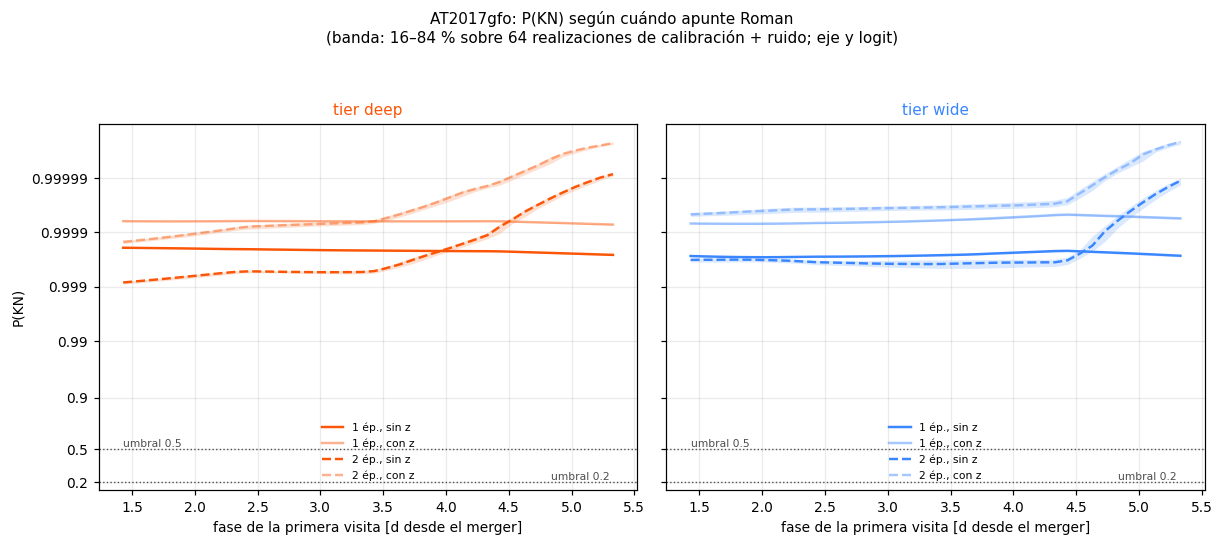

In [6]:
sweep_predictions = classify_all_regimes(
    sweep_windows, RELEASE_DIR / "at2017gfo_roman_sweep.parquet", classifier, device
)
axes = sweep_predictions["object_id"].str.split("_", expand=True)
sweep_predictions["tier"] = axes[1]
sweep_predictions["anchor_phase_days"] = axes[2].astype(float)
sweep_predictions["realization"] = axes[3].astype(int)

sweep_summary = (
    sweep_predictions.groupby(["tier", "epochs", "has_redshift", "anchor_phase_days"])["kn_probability"]
    .agg(
        median="median",
        percentile_16=lambda values: values.quantile(0.16),
        percentile_84=lambda values: values.quantile(0.84),
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
sweep_summary.to_csv(RELEASE_DIR / "at2017gfo_roman_phase_sweep.csv", index=False)

plot_probability_vs_phase(sweep_summary)
plt.savefig(RELEASE_DIR / "at2017gfo_roman_phase_sweep.pdf", bbox_inches="tight")

display(
    sweep_summary.groupby(["tier", "epochs", "has_redshift"])[["minimum", "median", "maximum"]]
    .agg({"minimum": "min", "median": "median", "maximum": "max"})
    .round(5)
)
print(
    "dispersión 16-84 máxima sobre todo el barrido (calibración + ruido de Roman): "
    f"{(sweep_summary['percentile_84'] - sweep_summary['percentile_16']).max():.2e} en P(KN)"
)

## 4. La frase para la discusión

Los números están en `at2017gfo_roman_phase_sweep.csv` y la figura en
`at2017gfo_roman_phase_sweep.pdf`. Lo que se lee ahí:

- **P(KN) no baja de 0.999 en ninguna parte del barrido.** Con la primera visita en cualquier fase
  entre +1.4 y +5.4 d, en cualquiera de los dos tiers, con una o dos épocas, con o sin redshift.
- **Ni la calibración ni el ruido mueven nada.** El intervalo 16–84 % es más angosto que 10⁻⁴ en
  P(KN) en todo el barrido, y esa banda ya contiene las dos incertezas: el error de la calibración
  espectrofotométrica del espectro (0.05 mag gris, 0.11 mag en el color R062−F184) y el ruido de
  Roman encima. A S/N ~ 10³ el clasificador está leyendo colores, y a 0.1 mag de error de color el
  objeto sigue estando lejísimos de cualquier contaminante. Es el chequeo que hace falta porque el
  primer término es ~20 veces mayor que el segundo y es el que un referato va a mirar.
- **Con una época, la fase da igual.** P(KN) se queda entre 0.99974 y 0.99981 en todo el barrido,
  sin tendencia: la primera visita de Roman puede caer donde caiga.
- **Con dos épocas, atrasar la primera visita ayuda mucho.** P(KN) pasa de 0.99915 con el ancla en
  +1.43 d a 0.99999 con el ancla en +5.4 d (deep, sin z) — la duda residual cae dos órdenes de
  magnitud — y no lo hace de forma monótona: hay una meseta entre +2.5 y +3.5 d. Con la segunda
  visita a +5 d del ancla, atrasar el ancla mueve el par de épocas a la parte de la curva donde la
  kilonova ya se enrojeció y el color se separa más de los contaminantes.
- **El redshift ayuda pero no hace falta.** Con z la duda residual 1 − P(KN) cae un factor 3 con una
  época y ~6 con dos; sin z, P(KN) sigue estando tres órdenes de magnitud por encima del umbral de
  decisión.

> Aplicado a AT2017gfo — la única kilonova con serie espectroscópica observada, propagada a las
> bandas de Roman **en el frame observado**, con su redshift y con la extinción galáctica dentro, y
> con la misma receta de ruido del HLTDS que el set de entrenamiento, y con el error de la
> calibración espectrofotométrica propagado — el clasificador la identifica
> con P(KN) > 0.999 **desde una sola época**, sin necesidad del redshift de la anfitriona ni de una
> segunda visita, y con independencia de en qué punto de los primeros cinco días caiga la primera
> visita de Roman.

Vale como argumento de que el modelo no está anclado a artefactos de la grilla LANL: cada kilonova
que vio en entrenamiento es una simulación sin extinción y por encima de z = 0.02, y esta es una
medición enrojecida por debajo de ese piso.

**Lo que no dice.** Es un objeto, un ángulo de visión, un juego de parámetros de eyecta, y un brillo
que está ~9 mag por encima del límite de detección del survey — o sea el caso más fácil posible en
S/N. No mide tasa de acierto sobre la diversidad de kilonovas que Roman va a encontrar, ni toca la
tasa de falsos positivos: eso está medido sobre el test split.

La nota hermana, `observed_photometry_roman_prediction.ipynb`, lleva el mismo checkpoint a la
**fotometría publicada** del mismo objeto — las compilaciones de Smartt y de Villar — y da una
clasificación por cada noche de los primeros 5 días, con los errores de medición reales propagados.
Es el control de que este número no depende de haber pasado por un espectro.